In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt

In [2]:
# --- 1. Завантаження даних ---
# Переконайся, що файл training_data.csv лежить у кореневій папці Colab

print("📥 Завантаження даних...")
df = pd.read_csv('training_data.csv', index_col='ts_rounded', parse_dates=True)

📥 Завантаження даних...


In [3]:
# Беремо тільки наші 3 фічі

data = df[['cpu', 'ram', 'rps']].values
print(f"📊 Загальна кількість записів: {len(data)}")

📊 Загальна кількість записів: 233


In [4]:
# --- 2. Нормалізація (StandardScaler) ---
# Навчаємо скейлер і відразу трансформуємо дані

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Зберігаємо скейлер (Він потрібен нашому API для нових даних!)
joblib.dump(scaler, 'scaler.pkl')
print("✅ Скейлер збережено як scaler.pkl")

✅ Скейлер збережено як scaler.pkl


In [5]:
# --- 3. Створення "вікон" (Sequences) ---

WINDOW_SIZE = 10  # Наш Воркер збирає по 10 точок

X, y = [], []
for i in range(len(data_scaled) - WINDOW_SIZE):
    X.append(data_scaled[i : i + WINDOW_SIZE])  # 10 кроків історії
    y.append(data_scaled[i + WINDOW_SIZE])      # 11-й крок (те, що прогнозуємо)

X = np.array(X)
y = np.array(y)

print(f"📐 Форма вхідних даних (X): {X.shape} -> (Батчі, Кроки, Фічі)")
print(f"📐 Форма вихідних даних (y): {y.shape} -> (Батчі, Фічі)")

📐 Форма вхідних даних (X): (223, 10, 3) -> (Батчі, Кроки, Фічі)
📐 Форма вихідних даних (y): (223, 3) -> (Батчі, Фічі)


In [6]:
# Розбиваємо на Train та Test (80% на навчання, 20% на перевірку)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [7]:
# --- 4. Побудова LSTM архітектури ---


model = tf.keras.Sequential([
    # Перший LSTM шар (32 нейрони). return_sequences=False, бо нам потрібен один фінальний прогноз
    tf.keras.layers.LSTM(32, activation='tanh', input_shape=(WINDOW_SIZE, 3)),

    # Додатковий щільний шар для кращого пошуку залежностей
    tf.keras.layers.Dense(16, activation='relu'),

    # Вихідний шар: 3 нейрони (бо ми прогнозуємо cpu, ram та rps одночасно)
    tf.keras.layers.Dense(3)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,187 (20.26 KB)

 Trainable params: 5,187 (20.26 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# --- 5. Тренування ---

print("🚀 Починаємо тренування моделі...")
history = model.fit(
    X_train, y_train,
    epochs=50,          # Кількість проходів по всьому датасету
    batch_size=16,      # По скільки вікон згодовувати за раз
    validation_data=(X_test, y_test),
    verbose=1
)

# --- 6. Збереження моделі ---
# Зберігаємо у форматі .h5, який очікує наш FastAPI додаток
model.save('lstm_model.h5')
print("\n✅ Модель успішно збережено як lstm_model.h5")

🚀 Починаємо тренування моделі...
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.6964 - mae: 0.6982 - val_loss: 0.5888 - val_mae: 0.7477
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5317 - mae: 0.6044 - val_loss: 0.3988 - val_mae: 0.6083
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3675 - mae: 0.4986 - val_loss: 0.2706 - val_mae: 0.4791
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2930 - mae: 0.4258 - val_loss: 0.2124 - val_mae: 0.3963
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2513 - mae: 0.3582 - val_loss: 0.2014 - val_mae: 0.3798
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1641 - mae: 0.2699 - val_loss: 0.2013 - val_mae: 0.3839
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1323 - mae: 0.2521 - val_loss: 0.1991 - val_mae: 0.3864
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1352 - mae: 0.2523 - val_loss: 0.1883 - val_mae: 0.3662
Epoch 9/50
12/12 ━━━━━━━━━━━━━━


✅ Модель успішно збережено як lstm_model.h5


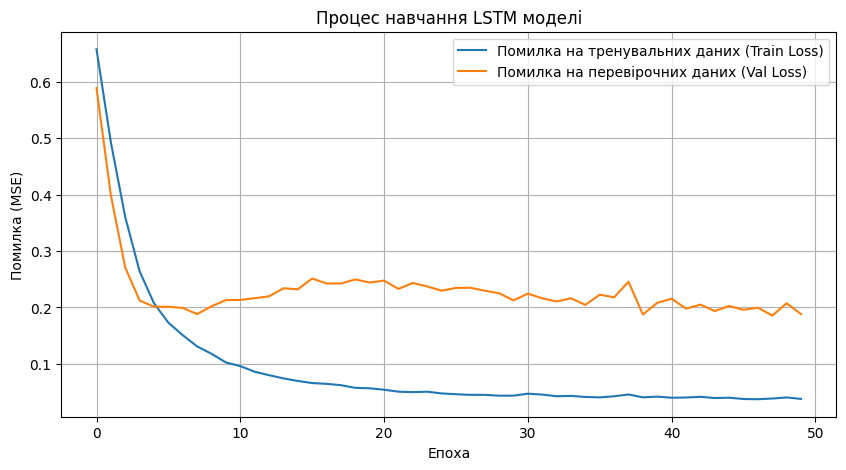

In [9]:
# --- 7. Візуалізація ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Помилка на тренувальних даних (Train Loss)')
plt.plot(history.history['val_loss'], label='Помилка на перевірочних даних (Val Loss)')
plt.title('Процес навчання LSTM моделі')
plt.xlabel('Епоха')
plt.ylabel('Помилка (MSE)')
plt.legend()
plt.grid(True)
plt.show()